02 — Mutation Rate Analysis (Generalized, Config-Driven)
=========================================================

QUESTION:
  Do the MROH gene copies show ELEVATED mutation rates compared to the
  genomic background? If so, this is strong evidence that the copies were
  generated via an RNA intermediate (reverse transcription), because:

    - Reverse transcriptase (RT) has a much higher error rate (~10^-4 per
      base per replication) than the DNA polymerase used in normal genome
      replication (~10^-9 per base).
    - If copies were made via RT, they should accumulate ~10-100x MORE
      substitutions than expected for DNA-only duplication.

REASONING:
  We compute the pairwise nucleotide divergence between all pairs of MROH
  copies using the Jukes-Cantor (JC69) correction, which accounts for
  multiple substitutions at the same site (saturation). We then compare the
  observed mean divergence to the genomic baseline for paralog divergence
  (~0.03 substitutions/site, from Lynch & Conery 2000).

  Additionally, we examine the Transition/Transversion (Ts/Tv) ratio:
    - RT errors are biased toward transitions (purine↔purine, pyrimidine↔
      pyrimidine), so Ts/Tv > 1 would further support the RT hypothesis.
    - Ts/Tv ~ 0.5 = random substitution pattern (no bias).

  We also partition divergence into:
    - Within ancestral copies (chr7 vs chr7)
    - Ancestral → Derived (chr7 vs other chromosomes)
    - Within derived copies (non-chr7 vs non-chr7)
  This reveals whether derived copies diverged FROM the ancestral locus
  (consistent with a single origin) or independently.

EXPECTED FINDINGS:
  - JC divergence >> genomic baseline (fold elevation > 3x) → RNA-mediated
  - JC divergence ~ genomic baseline → DNA-only duplication
  - Ts/Tv > 1 → RT signature; Ts/Tv < 1 → no clear RT bias
  - Ancestral→Derived divergence > Within-Derived → single radiation event

FINDINGS (Zebra Finch):
  - 13.5x elevation above baseline (p = 3.51e-56) → ROBUSTLY supports RNA
  - Ts/Tv median = 0.883 → below 1.0, ambiguous for RT signature
  - This may reflect sequence context effects or overlapping duplication events

Usage:
  python notebooks/02_mutation_rate.py --species melospiza_georgiana

In [1]:
import sys
from pathlib import Path

# Jupyter-compatible project root detection
_cwd = Path.cwd()
PROJECT = _cwd if (_cwd / 'scripts').exists() else _cwd.parent
sys.path.insert(0, str(PROJECT / 'scripts'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import AlignIO
from pathlib import Path
from scipy import stats as sp_stats

from utils import pairwise_divergence_matrix, count_substitution_types, jukes_cantor_distance
from species_config import load_config, get_data_dirs, classify_chrom


# ── SPECIES CONFIGURATION ──
# Change this to run a different species:
SPECIES_SLUG = "zebra_finch"  # or "melospiza_georgiana"

cfg = load_config(SPECIES_SLUG)
dirs = get_data_dirs(cfg)

DATA_PROC = dirs["data_proc"]
FIG_DIR = dirs["fig_dir"]
TABLE_DIR = dirs["table_dir"]
prefix = cfg["output_prefix"]

sns.set_context('notebook')
sns.set_style('whitegrid')

GENOMIC_BASELINE = cfg.get("genomic_baseline", 0.03)
GENE = cfg["gene_name"]
SPECIES = cfg["common_name"]

print("=" * 70)
print(f"  STEP 02: MUTATION RATE ANALYSIS — {GENE} in {SPECIES}")
print("=" * 70)

  STEP 02: MUTATION RATE ANALYSIS — MROH6 in Zebra finch


## 2a. Load alignment

In [2]:
# ── 2a. Load alignment ──────────────────────────────────────────────────
print("\n── 2a. Loading trimmed alignment ──")
aln_path = DATA_PROC / f'{prefix}_aligned_trimmed.fasta'

if not aln_path.exists():
    print(f"  ERROR: Trimmed alignment not found: {aln_path}")
    print(f"  Run Step 01 first with tBLASTn data.")
    sys.exit(1)

alignment = AlignIO.read(aln_path, 'fasta')
n_seqs = len(alignment)
aln_len = alignment.get_alignment_length()
print(f"  Alignment: {n_seqs} sequences x {aln_len} columns")

aln_dict = {rec.id: str(rec.seq) for rec in alignment}

# Load metadata for chromosome classification
loci_path = DATA_PROC / f'{prefix}_loci_table.csv'
loci_meta = pd.read_csv(loci_path)
if 'chrom_class' not in loci_meta.columns:
    loci_meta['chrom_class'] = loci_meta['chrom'].astype(str).apply(
        lambda c: classify_chrom(c, cfg))

# Map sequence IDs to chromosome class
id_to_chrom = {}
id_to_class = {}
for _, row in loci_meta.iterrows():
    locus_id = row.get('locus_id', row.get('gene_unit_id', ''))
    fasta_id = f"gu_{locus_id}_chr{row['chrom']}_{row['start']}_{row['end']}"
    id_to_chrom[fasta_id] = str(row['chrom'])
    id_to_class[fasta_id] = row['chrom_class']


── 2a. Loading trimmed alignment ──
  Alignment: 399 sequences x 1113 columns


## 2b. Compute pairwise divergence

In [3]:
# ── 2b. Compute pairwise divergence ─────────────────────────────────────
# WHY: Pairwise divergence is the fraction of sites that differ between two
# sequences. For N sequences, we compute N*(N-1)/2 pairwise comparisons.
# Raw divergence underestimates true evolutionary distance because some sites
# mutate multiple times (saturation). The Jukes-Cantor correction accounts
# for this: JC = -0.75 * ln(1 - 4/3 * p), where p = raw divergence.
# We also count transitions (A↔G, C↔T) vs transversions (purine↔pyrimidine)
# to test for reverse transcriptase bias.
print("\n── 2b. Computing pairwise divergence matrix ──")
print(f"  Computing {n_seqs * (n_seqs - 1) // 2} pairwise comparisons...")

names, raw_div, jc_div, ts_tv_mat = pairwise_divergence_matrix(aln_dict)

triu_idx = np.triu_indices(len(names), k=1)
raw_values = raw_div[triu_idx]
jc_values = jc_div[triu_idx]
tstv_values = ts_tv_mat[triu_idx]

jc_clean = jc_values[~np.isnan(jc_values)]
tstv_clean = tstv_values[np.isfinite(tstv_values)]

jc_mean = np.nanmean(jc_clean)
jc_median = np.nanmedian(jc_clean)
raw_mean = np.nanmean(raw_values)
tstv_median = np.nanmedian(tstv_clean)

fold_diff = jc_mean / GENOMIC_BASELINE if GENOMIC_BASELINE > 0 else np.nan
_, p_value = sp_stats.mannwhitneyu(
    jc_clean, [GENOMIC_BASELINE] * min(len(jc_clean), 100),
    alternative='greater'
)

print(f"  Raw divergence:  mean={raw_mean:.4f}")
print(f"  JC-corrected:    mean={jc_mean:.4f}, median={jc_median:.4f}")
print(f"  Ts/Tv ratio:     median={tstv_median:.4f}")
print(f"  Genomic baseline: {GENOMIC_BASELINE}")
print(f"  Fold elevation:  {fold_diff:.1f}x (p={p_value:.2e})")


── 2b. Computing pairwise divergence matrix ──
  Computing 79401 pairwise comparisons...
  Raw divergence:  mean=0.2919
  JC-corrected:    mean=0.4142, median=0.4163
  Ts/Tv ratio:     median=0.8956
  Genomic baseline: 0.03
  Fold elevation:  13.8x (p=4.03e-56)


## 2c. Ancestral vs Derived comparison

In [4]:
# ── 2c. Ancestral vs Derived comparison ──────────────────────────────────
# ── 2c. Ancestral vs Derived comparison ──────────────────────────────────
# WHY: The ancestral MROH copy sits adjacent to the LSS gene on the
# "source" chromosome (chr7 in songbirds). All other copies are "derived"
# — they arose by duplication FROM this ancestral locus (or from each other).
# By comparing divergence WITHIN the ancestral group vs BETWEEN ancestral
# and derived copies, we can distinguish:
#   - Single radiation: all derived copies are ~equally distant from chr7
#   - Ongoing duplication: some derived copies are very similar to chr7
#     (recent) while others are highly diverged (ancient)
#   - Secondary expansion: derived copies are more similar to EACH OTHER
#     than to chr7, suggesting they duplicated from a derived intermediate
anc_class = f"chr{cfg['ancestral_chromosome']}_ancestral"
print(f"\n── 2c. {anc_class} vs Derived divergence ──")

anc_ids = [n for n in names if id_to_class.get(n) == anc_class]
derived_ids = [n for n in names if id_to_class.get(n) != anc_class]

print(f"  Ancestral copies: {len(anc_ids)}")
print(f"  Derived copies: {len(derived_ids)}")

# Ancestral-to-derived divergence
anc_to_derived = []
for a in anc_ids:
    a_idx = names.index(a)
    for d in derived_ids:
        d_idx = names.index(d)
        val = jc_div[a_idx, d_idx]
        if not np.isnan(val):
            anc_to_derived.append(val)

# Within-ancestral divergence
anc_within = []
for i, a1 in enumerate(anc_ids):
    for a2 in anc_ids[i+1:]:
        val = jc_div[names.index(a1), names.index(a2)]
        if not np.isnan(val):
            anc_within.append(val)

# Within-derived divergence
derived_within = []
for i, d1 in enumerate(derived_ids[:100]):
    for d2 in derived_ids[i+1:i+100]:
        val = jc_div[names.index(d1), names.index(d2)]
        if not np.isnan(val):
            derived_within.append(val)

if anc_to_derived:
    print(f"  Ancestral → Derived mean JC:  {np.mean(anc_to_derived):.4f}")
if anc_within:
    print(f"  Within Ancestral mean JC:      {np.mean(anc_within):.4f}")
if derived_within:
    print(f"  Within Derived mean JC:        {np.mean(derived_within):.4f}")


── 2c. chr7_ancestral vs Derived divergence ──
  Ancestral copies: 8
  Derived copies: 391
  Ancestral → Derived mean JC:  0.5520
  Within Ancestral mean JC:      0.5106
  Within Derived mean JC:        0.3452


## Figure 1: Divergence distributions

/var/folders/bn/vvtblf_s1yd5pp7g7yybc2640000gn/T/ipykernel_74052/839158433.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([d for _, d in plot_data],


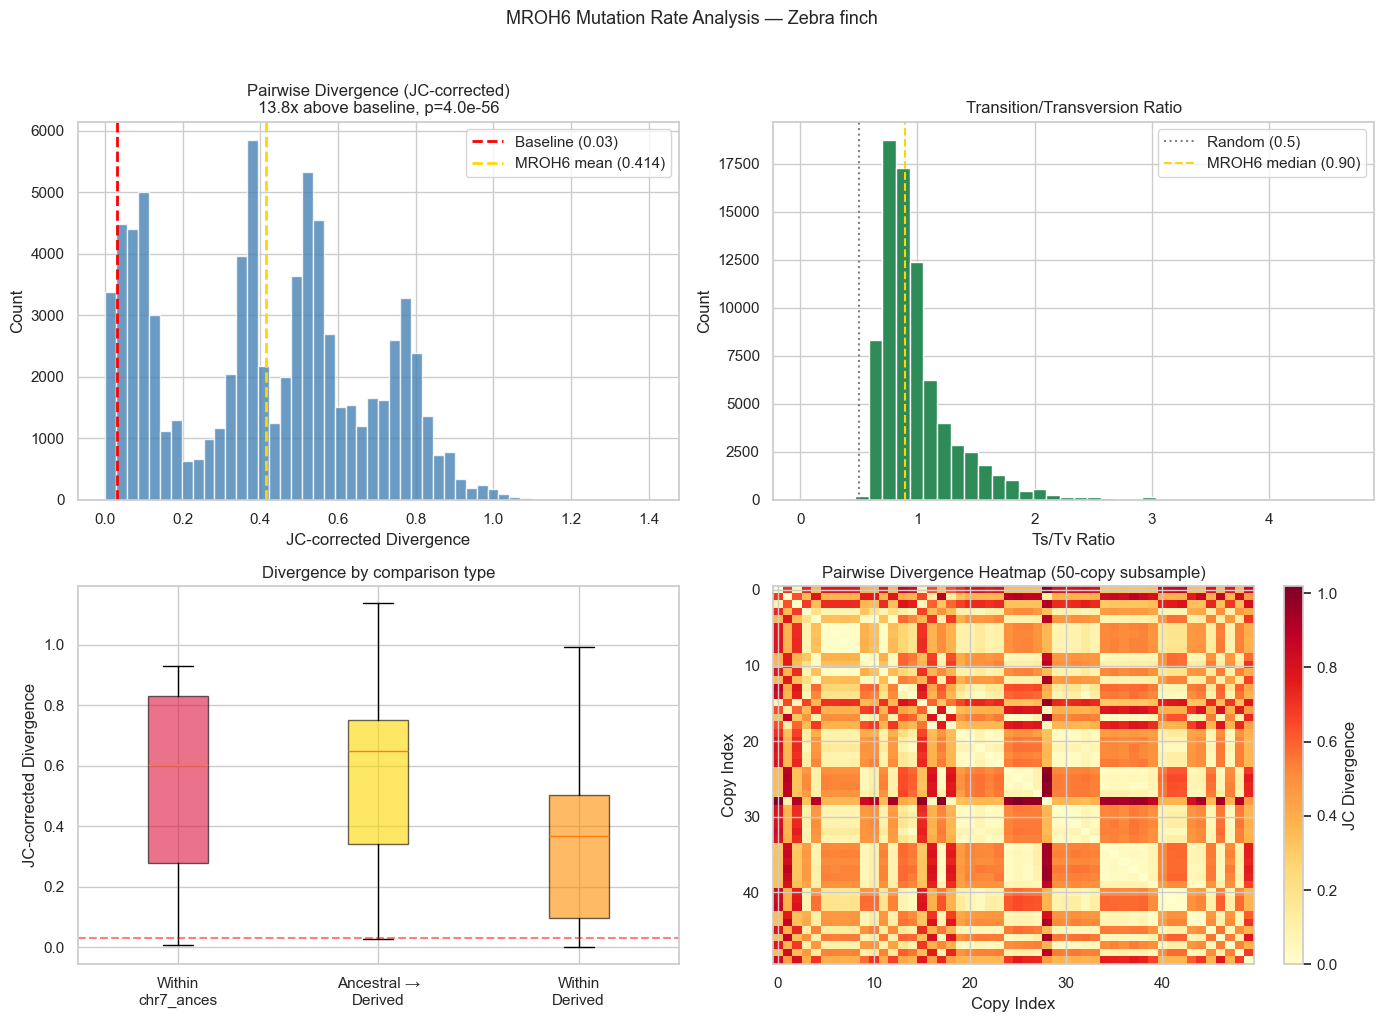


  Saved: /Users/makuachtenygatluak/Documents/Research/results/zebra_finch/figures/mutation_rate_analysis.png


In [5]:
# ── Figure 1: Divergence distributions ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.hist(jc_clean, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(GENOMIC_BASELINE, color='red', linestyle='--', linewidth=2,
           label=f'Baseline ({GENOMIC_BASELINE})')
ax.axvline(jc_mean, color='gold', linestyle='--', linewidth=2,
           label=f'{GENE} mean ({jc_mean:.3f})')
ax.set_xlabel('JC-corrected Divergence')
ax.set_ylabel('Count')
ax.set_title(f'Pairwise Divergence (JC-corrected)\n{fold_diff:.1f}x above baseline, p={p_value:.1e}')
ax.legend()

ax = axes[0, 1]
ax.hist(tstv_clean[tstv_clean < 5], bins=40, color='seagreen', edgecolor='white')
ax.axvline(0.5, color='gray', linestyle=':', label='Random (0.5)')
ax.axvline(tstv_median, color='gold', linestyle='--',
           label=f'{GENE} median ({tstv_median:.2f})')
ax.set_xlabel('Ts/Tv Ratio')
ax.set_ylabel('Count')
ax.set_title('Transition/Transversion Ratio')
ax.legend()

ax = axes[1, 0]
plot_data = []
if anc_within:
    plot_data.append((f'Within\n{anc_class[:10]}', anc_within))
if anc_to_derived:
    plot_data.append(('Ancestral →\nDerived', anc_to_derived))
if derived_within:
    plot_data.append(('Within\nDerived', derived_within))
if plot_data:
    bp = ax.boxplot([d for _, d in plot_data],
                    labels=[l for l, _ in plot_data],
                    patch_artist=True)
    box_colors = ['crimson', 'gold', 'darkorange']
    for patch, color in zip(bp['boxes'], box_colors[:len(plot_data)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
ax.set_ylabel('JC-corrected Divergence')
ax.set_title('Divergence by comparison type')
ax.axhline(GENOMIC_BASELINE, color='red', linestyle='--', alpha=0.5)

ax = axes[1, 1]
n_show = min(50, len(names))
show_idx = np.linspace(0, len(names)-1, n_show, dtype=int)
sub_matrix = jc_div[np.ix_(show_idx, show_idx)]
im = ax.imshow(sub_matrix, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax, label='JC Divergence')
ax.set_title(f'Pairwise Divergence Heatmap ({n_show}-copy subsample)')
ax.set_xlabel('Copy Index')
ax.set_ylabel('Copy Index')

plt.suptitle(f'{GENE} Mutation Rate Analysis — {SPECIES}', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'mutation_rate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n  Saved: {FIG_DIR / 'mutation_rate_analysis.png'}")

## Figure 2: Per-chromosome divergence

/var/folders/bn/vvtblf_s1yd5pp7g7yybc2640000gn/T/ipykernel_74052/3816541045.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='chrom', y='mean_jc_div', order=top_chroms,


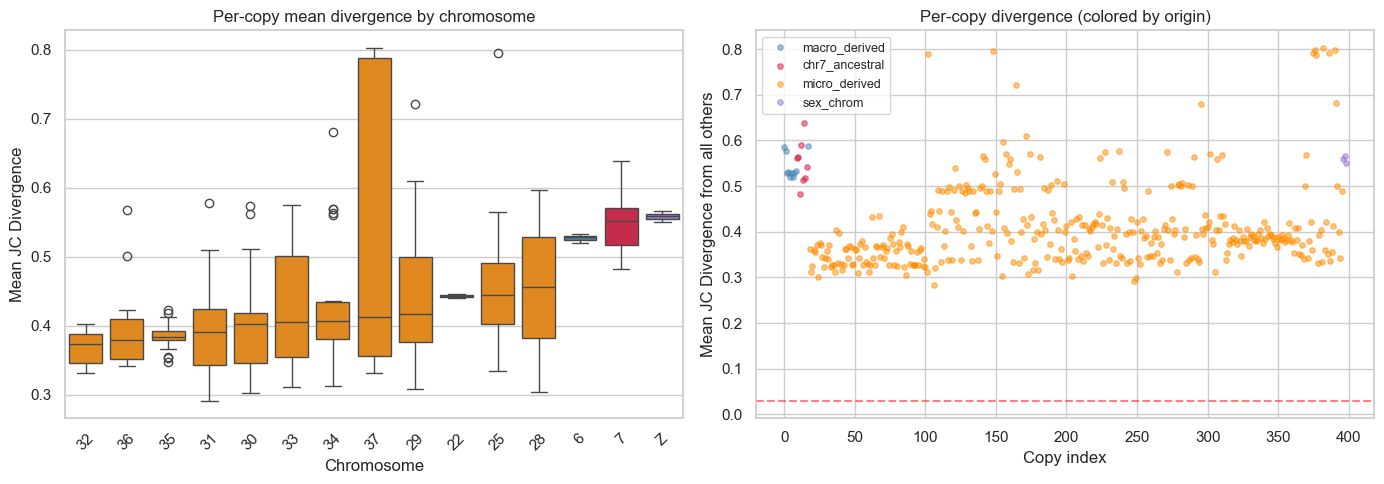

  Saved: /Users/makuachtenygatluak/Documents/Research/results/zebra_finch/figures/chr_vs_derived_scatter.png


In [6]:
# ── Figure 2: Per-chromosome divergence ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

per_copy = []
for i, name in enumerate(names):
    others = [j for j in range(len(names)) if j != i]
    mean_div = np.nanmean([jc_div[i, j] for j in others])
    chrom = id_to_chrom.get(name, 'unknown')
    cls = id_to_class.get(name, 'unknown')
    per_copy.append({'name': name, 'chrom': chrom, 'chrom_class': cls,
                     'mean_jc_div': mean_div})

per_copy_df = pd.DataFrame(per_copy)
per_copy_df.to_csv(TABLE_DIR / 'per_copy_divergence.csv', index=False)

ax = axes[0]
chrom_order = per_copy_df.groupby('chrom')['mean_jc_div'].median().sort_values().index
color_map = {}
for cls in per_copy_df['chrom_class'].unique():
    if 'ancestral' in cls:
        color_map[cls] = 'crimson'
    elif cls == 'macro_derived':
        color_map[cls] = 'steelblue'
    elif cls == 'sex_chrom':
        color_map[cls] = 'mediumpurple'
    else:
        color_map[cls] = 'darkorange'

top_chroms = [c for c in chrom_order if
              len(per_copy_df[per_copy_df['chrom'] == c]) >= 2][-15:]
sub = per_copy_df[per_copy_df['chrom'].isin(top_chroms)]
if len(sub) > 0:
    chrom_class_map = sub.groupby('chrom')['chrom_class'].first()
    palette = {c: color_map.get(chrom_class_map.get(c, ''), 'gray') for c in top_chroms}
    sns.boxplot(data=sub, x='chrom', y='mean_jc_div', order=top_chroms,
                palette=palette, ax=ax)
    ax.set_xlabel('Chromosome')
    ax.set_ylabel('Mean JC Divergence')
    ax.set_title('Per-copy mean divergence by chromosome')
    ax.tick_params(axis='x', rotation=45)

ax = axes[1]
for cls, color in color_map.items():
    mask = per_copy_df['chrom_class'] == cls
    if mask.any():
        ax.scatter(per_copy_df.loc[mask].index,
                   per_copy_df.loc[mask, 'mean_jc_div'],
                   c=color, alpha=0.5, s=15, label=cls)
ax.set_xlabel('Copy index')
ax.set_ylabel('Mean JC Divergence from all others')
ax.set_title('Per-copy divergence (colored by origin)')
ax.legend(fontsize=9)
ax.axhline(GENOMIC_BASELINE, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(FIG_DIR / 'chr_vs_derived_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved: {FIG_DIR / 'chr_vs_derived_scatter.png'}")

## Save summary table

In [7]:
# ── Save summary table ───────────────────────────────────────────────────
summary = pd.DataFrame([
    {'Metric': 'Species', 'Value': cfg['species_name']},
    {'Metric': 'Gene', 'Value': GENE},
    {'Metric': 'Number of sequences', 'Value': n_seqs},
    {'Metric': 'Alignment columns', 'Value': aln_len},
    {'Metric': 'JC-corrected mean', 'Value': f'{jc_mean:.4f}'},
    {'Metric': 'JC-corrected median', 'Value': f'{jc_median:.4f}'},
    {'Metric': 'Raw divergence mean', 'Value': f'{raw_mean:.4f}'},
    {'Metric': 'Ts/Tv median', 'Value': f'{tstv_median:.4f}'},
    {'Metric': 'Genomic baseline', 'Value': f'{GENOMIC_BASELINE}'},
    {'Metric': 'Fold elevation', 'Value': f'{fold_diff:.1f}x'},
    {'Metric': 'P-value', 'Value': f'{p_value:.2e}'},
    {'Metric': 'Ancestral copies', 'Value': len(anc_ids)},
    {'Metric': 'Derived copies', 'Value': len(derived_ids)},
    {'Metric': 'Ancestral→Derived mean JC',
     'Value': f'{np.mean(anc_to_derived):.4f}' if anc_to_derived else 'N/A'},
    {'Metric': 'Within Ancestral mean JC',
     'Value': f'{np.mean(anc_within):.4f}' if anc_within else 'N/A'},
])
summary.to_csv(TABLE_DIR / 'mutation_rate_summary.csv', index=False)

if fold_diff > 3 and p_value < 0.05:
    verdict = "ROBUSTLY ELEVATED — supports RNA-mediated hypothesis"
elif fold_diff > 1.5 and p_value < 0.05:
    verdict = "MODERATELY ELEVATED — proceed with caution"
else:
    verdict = "NOT ELEVATED — consistent with DNA-mediated duplication"

print("\n" + "=" * 70)
print(f"  MUTATION RATE ANALYSIS SUMMARY — {GENE} in {SPECIES}")
print("=" * 70)
print(f"  JC-corrected mean:   {jc_mean:.4f}")
print(f"  Genomic baseline:    {GENOMIC_BASELINE}")
print(f"  Fold elevation:      {fold_diff:.1f}x (p={p_value:.2e})")
print(f"  Ts/Tv median:        {tstv_median:.4f} (>0.5 = transition bias)")
print(f"  Verdict:             {verdict}")
print(f"\n  => Proceed to Step 03 (dN/dS analysis)")
print("=" * 70)


  MUTATION RATE ANALYSIS SUMMARY — MROH6 in Zebra finch
  JC-corrected mean:   0.4142
  Genomic baseline:    0.03
  Fold elevation:      13.8x (p=4.03e-56)
  Ts/Tv median:        0.8956 (>0.5 = transition bias)
  Verdict:             ROBUSTLY ELEVATED — supports RNA-mediated hypothesis

  => Proceed to Step 03 (dN/dS analysis)
